,ExtractRows,SlashPlanRows,OkRows,Patients,Sessions,Plans,Metrics,ExpectedRows
0,3110,3110,3110,10,311,622,5,3110


Status
OkNormalized    3110
Name: StatusCount, dtype: int64

MetricId
V95% PTV2          622
V95% PTV3          622
V107% PTV2-PTV1    622
V107% PTV3-PTV2    622
D1.8cm3 PTV1       622
Name: MetricCount, dtype: int64

,RequestedStructureId,ActualStructureId,Status,Count
0,PTV1,PTV1_66,OkNormalized,66
1,PTV1,PTV1_68,OkNormalized,556
2,PTV2,PTV2_60,OkNormalized,622
3,PTV2-PTV1,PTV2_60-PTV1_66,OkNormalized,66
4,PTV2-PTV1,PTV2_60-PTV1_68,OkNormalized,556
5,PTV3,PTV3_50,OkNormalized,622
6,PTV3-PTV2,PTV3_50-PTV2_60,OkNormalized,622


,MetricId,MayoQuery,OriginalPrescriptionGy,IntendedFractions,CurrentFractions,FullCourseDoseThresholdGy,RawValue,Value,NormalizationFactor
0,V95% PTV2,V83.8235%[%],68,34,34,57.0,99.518603,99.518603,1.0
1,V95% PTV3,V69.8529%[%],68,34,34,47.5,99.784095,99.784095,1.0
2,V107% PTV2-PTV1,V94.4118%[%],68,34,34,64.2,20.002990,20.002990,1.0
3,V107% PTV3-PTV2,V78.6765%[%],68,34,34,53.5,0.178601,0.178601,1.0
4,D1.8cm3 PTV1,D1.8cc[Gy],68,34,34,NaN,69.960734,69.960734,1.0
5,V95% PTV2,V83.8235%[%],68,34,34,57.0,99.885332,99.885332,1.0
6,V95% PTV3,V69.8529%[%],68,34,34,47.5,99.960542,99.960542,1.0
7,V107% PTV2-PTV1,V94.4118%[%],68,34,34,64.2,6.238165,6.238165,1.0
8,V107% PTV3-PTV2,V78.6765%[%],68,34,34,53.5,0.034148,0.034148,1.0
9,D1.8cm3 PTV1,D1.8cc[Gy],68,34,34,NaN,70.352552,70.352552,1.0


,count,mean,std,min,25%,50%,75%,max
MetricId,,,,,,,,
D1.8cm3 PTV1,622.0,70.181,1.575,67.207,69.590,70.144,70.629,80.927
V107% PTV2-PTV1,622.0,27.327,15.330,0.001,15.480,25.982,38.157,65.335
V107% PTV3-PTV2,622.0,1.842,2.577,0.000,0.195,0.856,2.340,14.432
V95% PTV2,622.0,99.440,0.773,94.587,99.187,99.767,99.951,99.999
V95% PTV3,622.0,99.538,0.636,95.877,99.229,99.861,99.978,100.000


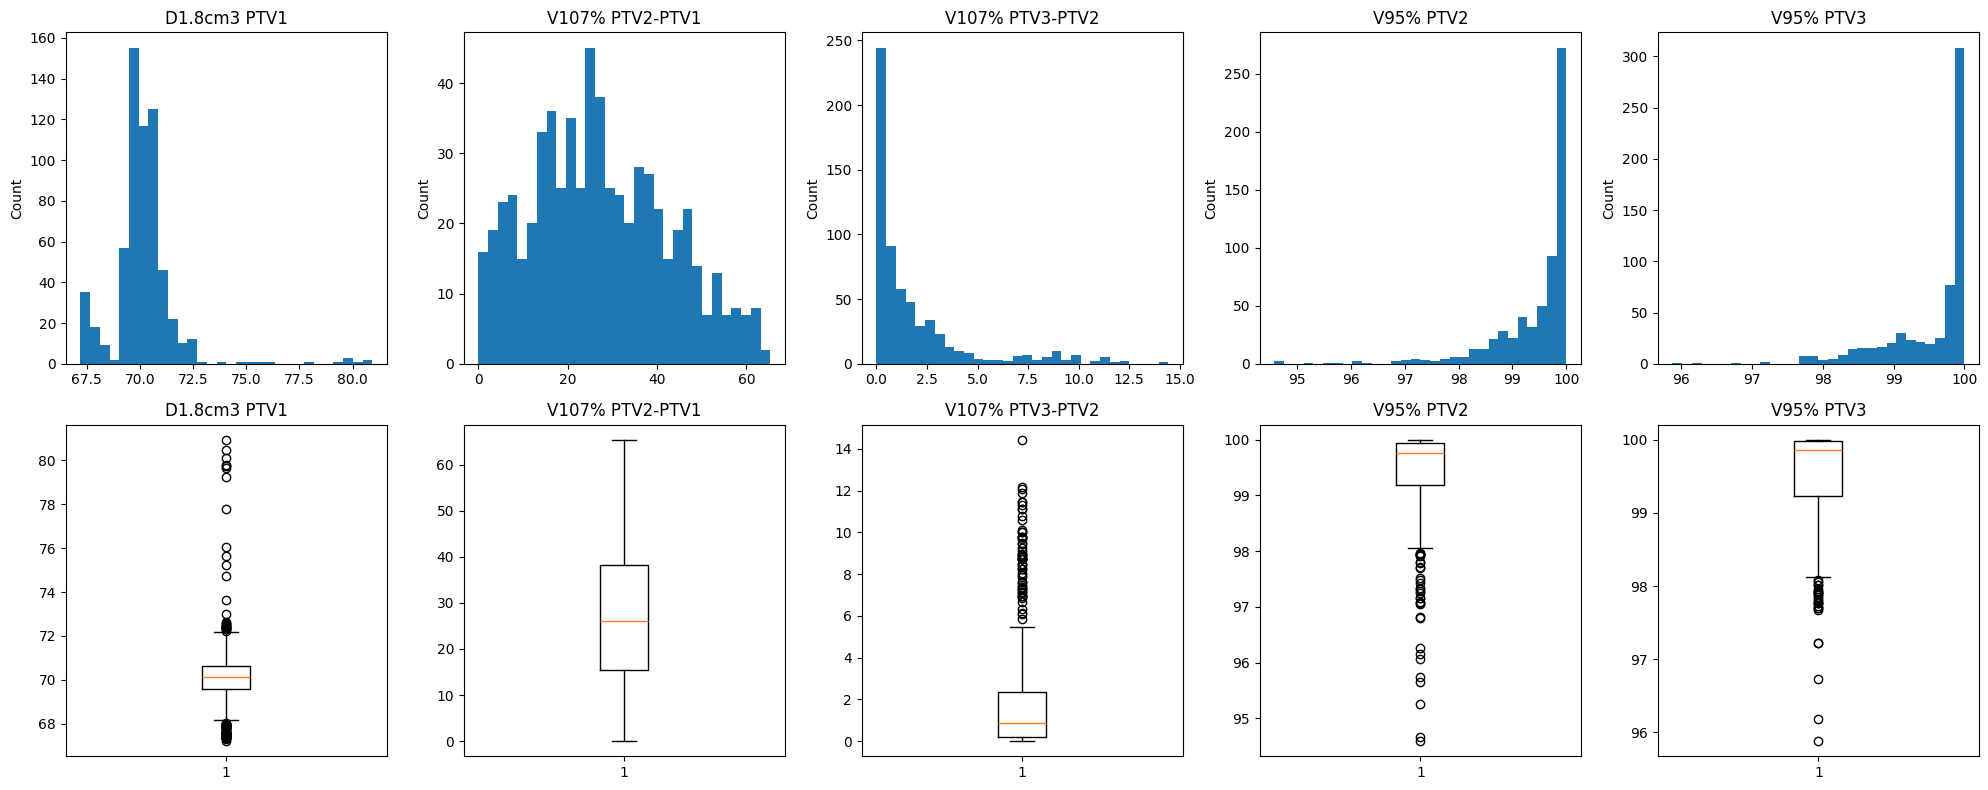

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("data-Jun25")

extract = pd.read_csv(data_dir / "pqm_extract.csv")
debug = pd.read_csv(data_dir / "pqm_plan_debug.csv")
dose_debug = pd.read_csv(data_dir / "pqm_plan_dose_debug.csv")

for d in [extract, debug, dose_debug]:
    for col in d.columns:
        if col in [
            "Value", "RawValue", "NormalizationFactor",
            "OriginalPrescriptionGy", "IntendedFractions",
            "CurrentFractions", "FullCourseDoseThresholdGy"
        ]:
            d[col] = pd.to_numeric(d[col], errors="coerce")

extract_slash = extract[
    extract["PlanId"].fillna("").str.contains("/", regex=False)
].copy()

ok = extract_slash[
    extract_slash["Status"].astype(str).str.startswith("Ok")
].copy()

summary = pd.DataFrame([{
    "ExtractRows": len(extract),
    "SlashPlanRows": len(extract_slash),
    "OkRows": len(ok),
    "Patients": ok["PatientId"].nunique(),
    "Sessions": ok[["PatientId", "CourseId"]].drop_duplicates().shape[0],
    "Plans": ok[["PatientId", "CourseId", "PlanId"]].drop_duplicates().shape[0],
    "Metrics": ok["MetricId"].nunique(),
    "ExpectedRows": (
        ok[["PatientId", "CourseId", "PlanId"]].drop_duplicates().shape[0]
        * ok["MetricId"].nunique()
    )
}])

display(summary)
display(extract_slash["Status"].value_counts(dropna=False).rename("StatusCount"))
display(ok["MetricId"].value_counts().rename("MetricCount"))
display(ok.groupby(["RequestedStructureId", "ActualStructureId", "Status"]).size().reset_index(name="Count"))
display(ok[[
    "MetricId", "MayoQuery", "OriginalPrescriptionGy", "IntendedFractions",
    "CurrentFractions", "FullCourseDoseThresholdGy", "RawValue", "Value",
    "NormalizationFactor"
]].head(20))

wide = (
    ok.pivot_table(
        index=["PatientId", "CourseId", "PlanId"],
        columns="MetricId",
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

display(ok.groupby("MetricId")["Value"].describe().round(3))

metrics = sorted(ok["MetricId"].unique())
fig, axes = plt.subplots(2, len(metrics), figsize=(4 * len(metrics), 8))

for i, metric in enumerate(metrics):
    values = ok.loc[ok["MetricId"] == metric, "Value"].dropna()
    axes[0, i].hist(values, bins=30)
    axes[0, i].set_title(metric)
    axes[0, i].set_ylabel("Count")

    axes[1, i].boxplot(values, vert=True)
    axes[1, i].set_title(metric)

plt.tight_layout()
plt.show()

,OriginalPrescriptionGy,IntendedFractions,CurrentFractions,Count,Min,Median,Max
0,66,33,1,2,33.000000,33.000000,33.000000
1,66,33,2,2,16.500000,16.500000,16.500000
2,66,33,3,2,11.000000,11.000000,11.000000
3,66,33,4,2,8.250000,8.250000,8.250000
4,66,33,5,2,6.600000,6.600000,6.600000
...,...,...,...,...,...,...,...
62,68,34,30,10,1.133333,1.133333,1.133333
63,68,34,31,10,1.096774,1.096774,1.096774
64,68,34,32,10,1.062500,1.062500,1.062500
65,68,34,33,10,1.030303,1.030303,1.030303


,PatientId,CourseId,PlanId,OriginalPrescriptionGy,IntendedFractions,CurrentFractions,RawValue,Value,NormalizationFactor
1639,99DART-HN_5,Session 34,IM113/ADP3403,68,34,1,2.096461,71.279661,34.000000
1634,99DART-HN_5,Session 34,IM113/SCH3404,68,34,1,2.099379,71.378870,34.000000
1974,99DART-HN_6,Session 34,IM122/ADP3403,68,34,1,2.092993,71.161747,34.000000
1979,99DART-HN_6,Session 34,IM122/SCH3404,68,34,1,2.097521,71.315724,34.000000
2814,99DART-HN_9,Session 34,IM108/ADP3403,68,34,1,2.096690,71.287468,34.000000
2819,99DART-HN_9,Session 34,IM108/SCH3404,68,34,1,2.099126,71.370276,34.000000
2474,99DART-HN_8,Session 33,IM107/ADP3303,66,33,1,2.095555,69.153321,33.000000
2479,99DART-HN_8,Session 33,IM107/SCH3304,66,33,1,2.097500,69.217486,33.000000
1624,99DART-HN_5,Session 33,IM113/ADP3304,68,34,2,4.099155,69.685636,17.000000
1629,99DART-HN_5,Session 33,IM113/SCH3303,68,34,2,4.198931,71.381821,17.000000


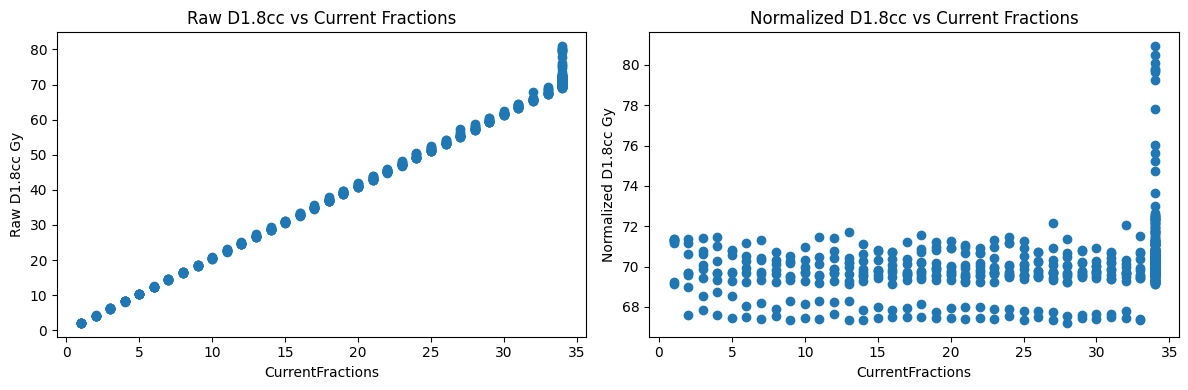

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

d1 = ok[ok["MetricId"] == "D1.8cm3 PTV1"].copy()

display(
    d1.groupby(["OriginalPrescriptionGy", "IntendedFractions", "CurrentFractions"])["NormalizationFactor"]
    .agg(Count="count", Min="min", Median="median", Max="max")
    .reset_index()
    .sort_values(["OriginalPrescriptionGy", "CurrentFractions"])
)

display(
    d1[["PatientId", "CourseId", "PlanId", "OriginalPrescriptionGy", "IntendedFractions",
        "CurrentFractions", "RawValue", "Value", "NormalizationFactor"]]
    .sort_values(["NormalizationFactor", "PatientId", "CourseId", "PlanId"], ascending=[False, True, True, True])
    .head(40)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(d1["CurrentFractions"], d1["RawValue"])
axes[0].set_title("Raw D1.8cc vs Current Fractions")
axes[0].set_xlabel("CurrentFractions")
axes[0].set_ylabel("Raw D1.8cc Gy")

axes[1].scatter(d1["CurrentFractions"], d1["Value"])
axes[1].set_title("Normalized D1.8cc vs Current Fractions")
axes[1].set_xlabel("CurrentFractions")
axes[1].set_ylabel("Normalized D1.8cc Gy")

plt.tight_layout()
plt.show()


In [7]:
sessions_per_patient = (
    ok[["PatientId", "CourseId"]]
    .drop_duplicates()
    .groupby("PatientId")
    .size()
    .rename("SessionCount")
    .reset_index()
    .sort_values("PatientId")
)

display(sessions_per_patient)
print("Total sessions:", sessions_per_patient["SessionCount"].sum())


,PatientId,SessionCount
0,99DART-HN_1,34
1,99DART-HN_10,23
2,99DART-HN_2,34
3,99DART-HN_3,34
4,99DART-HN_4,34
5,99DART-HN_5,34
6,99DART-HN_6,34
7,99DART-HN_7,17
8,99DART-HN_8,33
9,99DART-HN_9,34


Total sessions: 311
